**Table of contents**<a id='toc0_'></a>    
1.1. [Load Data](#toc1_1_)    
1.2. [Data Visualization](#toc1_2_)    
1.3. [Assumptions Check](#toc1_3_)    
1.3.1. [Dependency check](#toc1_3_1_)    
1.3.2. [Normality & Homoscedasticity Assumptions Check](#toc1_3_2_)    
1.4. [Analyse of Variances](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [67]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets
import pingouin as pg


In [68]:
plt.style.use('seaborn-v0_8-notebook')

## 1.1. <a id='toc1_1_'></a>[Load Data](#toc0_)

In [69]:
import openpyxl as xl

sheet_names= xl.load_workbook("data/data_num.xlsx").sheetnames

def load_data(file_path="data/data_num.xlsx", sheet=sheet_names[0]):
    return pd.read_excel(file_path, sheet_name=sheet)
df_widgets = widgets.interactive(
    load_data,
    sheet=widgets.Dropdown(options=sheet_names, value=sheet_names[0])
    )
df_widgets

interactive(children=(Text(value='data/data_num.xlsx', description='file_path'), Dropdown(description='sheet',…

In [70]:
df = pd.read_excel("data/data.xlsx")
df.drop(columns=["Date"], inplace=True)
df.head()

,LC2A,MP2,MP1,MC
0,721.0,870.75,845.12,850.2
1,650.0,760.20,848.10,889.8
2,644.0,638.40,749.00,682.3
3,636.0,552.70,741.00,658.2
4,649.0,607.42,755.40,670.2


In [71]:
stats_summary = df.describe(include=[np.number])

stats_summary: pd.DataFrame = pd.concat(
    [
        stats_summary.describe(include=[np.number]),
        stats_summary.agg(
            [stats.skew, stats.kurtosis]
        ),
    ],
    axis=1,
)

stats_summary

,LC2A,MP2,MP1,MC,LC2A,MP2,MP1,MC
count,8.000000,8.000000,8.000000,8.000000,NaN,NaN,NaN,NaN
mean,549.602863,531.386128,558.673752,552.516737,NaN,NaN,NaN,NaN
std,319.646212,309.406710,325.341666,321.493605,NaN,NaN,NaN,NaN
min,19.000000,23.000000,23.000000,23.000000,NaN,NaN,NaN,NaN
25%,492.218883,423.052473,484.631418,445.539398,NaN,NaN,NaN,NaN
50%,688.473684,654.175000,707.282174,686.950000,NaN,NaN,NaN,NaN
75%,733.750000,699.884348,745.300000,726.769728,NaN,NaN,NaN,NaN
max,811.000000,870.750000,848.100000,889.800000,NaN,NaN,NaN,NaN
skew,NaN,NaN,NaN,NaN,-1.054697,-0.839884,-1.028689,-0.888397
kurtosis,NaN,NaN,NaN,NaN,-0.727892,-0.825742,-0.745595,-0.809802


## 1.2. <a id='toc1_2_'></a>[Viz Correlation](#toc0_)

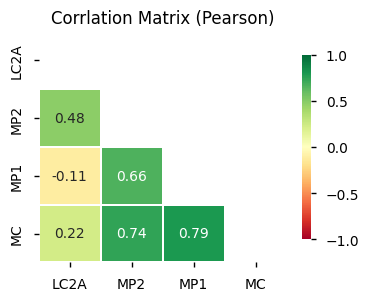

In [72]:
# check dependency between groups
corr_matrix = df.corr(numeric_only=True)
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
plt.figure(figsize=[4,3])
sns.heatmap(corr_matrix, 
			mask=upper_mask,
			linewidths=0.1,
			cbar_kws={'shrink':0.8},
			annot=True, vmax=1, vmin=-1, cmap='RdYlGn')
plt.title("Corrlation Matrix (Pearson)");


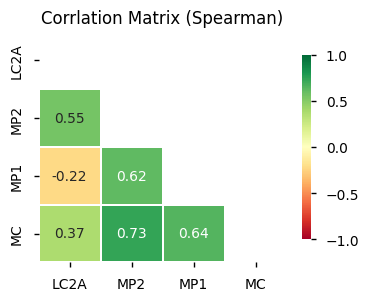

In [73]:
# check dependency between groups
corr_matrix = df.corr(numeric_only=True, method='spearman')
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
plt.figure(figsize=[4,3])
sns.heatmap(corr_matrix, 
			mask=upper_mask,
			linewidths=0.1,
			cbar_kws={'shrink':0.8},
			annot=True, vmax=1, vmin=-1, cmap='RdYlGn')
plt.title("Corrlation Matrix (Spearman)");


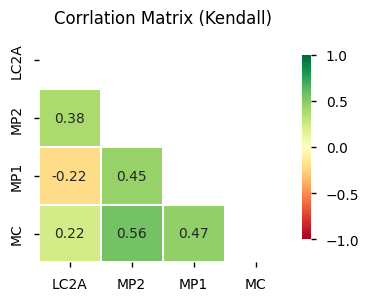

In [74]:
# check dependency between groups
corr_matrix = df.corr(numeric_only=True, method='kendall')
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
plt.figure(figsize=[4,3])
sns.heatmap(corr_matrix, 
			mask=upper_mask,
			linewidths=0.1,
			cbar_kws={'shrink':0.8},
			annot=True, vmax=1, vmin=-1, cmap='RdYlGn')
plt.title("Corrlation Matrix (Kendall)");


interval columns not set, guessing: ['LC2A', 'MP2', 'MP1', 'MC']


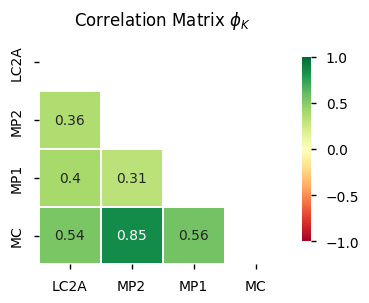

In [75]:
import phik
from phik import resources, report

# open fake car insurance data


# Pearson's correlation matrix between numeric variables (pandas functionality)

# get the phi_k correlation matrix between all variables
corr_matrix = df.phik_matrix()
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
plt.figure(figsize=[4,3])
sns.heatmap(corr_matrix, 
			mask=upper_mask,
			linewidths=0.1,
			cbar_kws={'shrink':0.8},
			annot=True, vmax=1, vmin=-1, cmap='RdYlGn')
plt.title(r'Correlation Matrix $\phi_K$');


interval columns not set, guessing: ['LC2A', 'MP2', 'MP1', 'MC']


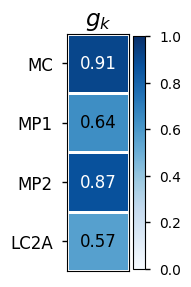

In [77]:

# get global correlations based on phi_k correlation matrix
global_correlation, global_labels = df.global_phik()
report.plot_correlation_matrix(global_correlation, x_labels=[''], y_labels=global_labels, 
                        vmin=0, vmax=1, figsize=(2,3),
                        color_map='Blues', title=r'$g_k$',
                        fontsize_factor=1.2)
plt.tight_layout()
